In [3]:
import os
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 80

# 1. Experience distribution skewed heavily toward early-career entries
experience = np.random.exponential(scale=4.0, size=n_samples)
experience = np.clip(experience, 0.2, 20.0) # From ~2 months to 20 years

salaries = []

for exp in experience:
    if exp <= 2.0:
        # Early Career / Locum reliance / Underemployment
        # Captures Low retail offers (12k-28k) up to formal internship/entry scale (30k-50k)
        base = np.random.choice([
            np.random.uniform(12000, 28000),  # Low-end retail / partial Locums
            np.random.uniform(30000, 50000),  # Standard entry-level peer range
            np.random.uniform(50000, 65000)   # Institutional / government entry
        ], p=[0.35, 0.50, 0.15])
    elif exp <= 5.0:
        # Mid-transition (50k - 110k)
        base = 45000 + (exp * 12000) + np.random.normal(0, 10000)
    else:
        # 5+ Years (Mid to Senior / Regulatory / Industry divergence)
        base = 70000 + (exp * 15000) + np.random.normal(0, 25000)

    salaries.append(max(12000, base)) # Floor at 12,000 KES

df_pharmacist_salaries = pd.DataFrame({
    'Years_Experience': np.round(experience, 1),
    'Monthly_Salary_KES': np.round(salaries, -2)
}).sort_values('Years_Experience').reset_index(drop=True)

# Define the exact directory target path
target_dir = r"C:\Users\ADMIN\Downloads\career progression\DATA ANALYSIS\projects\models"

# Ensure directory exists before writing file
os.makedirs(target_dir, exist_ok=True)

# Save to destination CSV
file_path = os.path.join(target_dir, "pharmacist_salaries_ke.csv")
df_pharmacist_salaries.to_csv(file_path, index=False)

print(f"Dataset successfully created and saved to: {file_path}")
print(df_pharmacist_salaries.head(15))

Dataset successfully created and saved to: C:\Users\ADMIN\Downloads\career progression\DATA ANALYSIS\projects\models\pharmacist_salaries_ke.csv
    Years_Experience  Monthly_Salary_KES
0                0.2             37900.0
1                0.2             35900.0
2                0.2             25100.0
3                0.2             20400.0
4                0.2             34800.0
5                0.2             17000.0
6                0.3             23200.0
7                0.3             40700.0
8                0.3             59200.0
9                0.4             47000.0
10               0.4             33500.0
11               0.5             47500.0
12               0.5             40900.0
13               0.6             13900.0
14               0.6             36300.0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load data
file_path = r"C:\Users\ADMIN\Downloads\career progression\DATA ANALYSIS\projects\models\pharmacist_salaries_ke.csv"
df = pd.read_csv(file_path)

# 2. Assign features (X) and target (y)
X = df[['Years_Experience']]
y = df['Monthly_Salary_KES']

# 3. Train Baseline Linear Regression
lm = LinearRegression()
lm.fit(X, y)
yp_linear = lm.predict(X)

# 4. Evaluate Baseline
rmse_linear = np.sqrt(mean_squared_error(y, yp_linear))
mae_linear = mean_absolute_error(y, yp_linear)
r2_linear = r2_score(y, yp_linear)

print("--- BASELINE LINEAR REGRESSION ---")
print(f"RMSE: KES {rmse_linear:,.2f}")
print(f"MAE:  KES {mae_linear:,.2f}")
print(f"R²:   {r2_linear:.3f}")

--- BASELINE LINEAR REGRESSION ---
RMSE: KES 23,791.35
MAE:  KES 16,835.09
R²:   0.907


In [6]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Polynomial transformation
pf = PolynomialFeatures(degree=2)
X_poly = pf.fit_transform(X)

# 2. Train Polynomial Model
lm_poly = LinearRegression()
lm_poly.fit(X_poly, y)
yp_poly = lm_poly.predict(X_poly)

# 3. Evaluate Polynomial Model
rmse_poly = np.sqrt(mean_squared_error(y, yp_poly))
mae_poly = mean_absolute_error(y, yp_poly)
r2_poly = r2_score(y, yp_poly)

print("\n--- POLYNOMIAL REGRESSION (DEGREE 2) ---")
print(f"RMSE: KES {rmse_poly:,.2f}")
print(f"MAE:  KES {mae_poly:,.2f}")
print(f"R²:   {r2_poly:.3f}")


--- POLYNOMIAL REGRESSION (DEGREE 2) ---
RMSE: KES 23,018.32
MAE:  KES 16,929.65
R²:   0.913


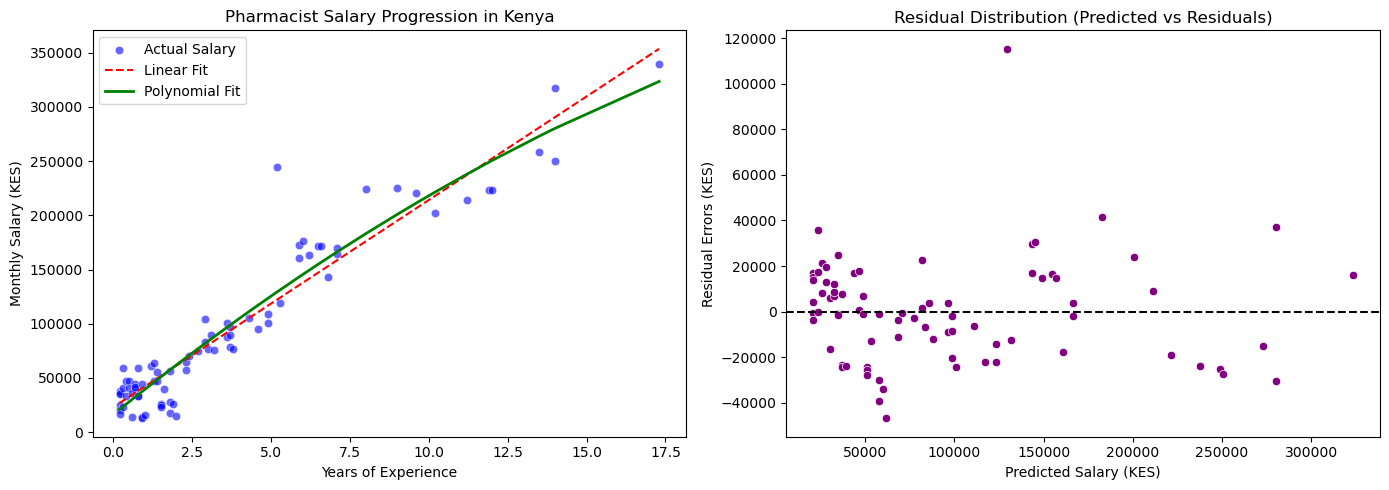

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Model Fit Comparison
sns.scatterplot(x='Years_Experience', y='Monthly_Salary_KES', data=df, ax=axes[0], color='blue', label='Actual Salary', alpha=0.6)
axes[0].plot(df['Years_Experience'], yp_linear, color='red', linestyle='--', label='Linear Fit')
axes[0].plot(df['Years_Experience'], yp_poly, color='green', linewidth=2, label='Polynomial Fit')
axes[0].set_title("Pharmacist Salary Progression in Kenya")
axes[0].set_xlabel("Years of Experience")
axes[0].set_ylabel("Monthly Salary (KES)")
axes[0].legend()

# Plot 2: Residuals Plot (Polynomial Model)
residuals = y - yp_poly
sns.scatterplot(x=yp_poly, y=residuals, ax=axes[1], color='purple')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Residual Distribution (Predicted vs Residuals)")
axes[1].set_xlabel("Predicted Salary (KES)")
axes[1].set_ylabel("Residual Errors (KES)")

plt.tight_layout()
plt.show()